# Análisis Exploratorio de Datos: Titanic

En esta actividad usaremos la base de datos de pasajeros del Titanic para practicar **análisis exploratorio de datos (EDA)**.

El objetivo no es hacer la mayor cantidad posible de gráficos, sino aprender a **usar los datos para responder preguntas**.

## Pregunta de investigación

> **¿Qué características de los pasajeros estaban asociadas con la supervivencia en el Titanic?**


## Librerías de visualización
### Matplotlib

Matplotlib tiene dos métodos para crear una figura, uno directo y otro enfocado a objetos. 
Algunos links de interés:

- Argumentos que reciben matplotlib: https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.plot.html
- Más opciones de gráficos en https://matplotlib.org/2.0.2/gallery.html
- Para una lista de colores disponibles en Matplotlib, https://matplotlib.org/stable/gallery/color/named_colors.html
- Explicación de plt y ax https://towardsdatascience.com/what-are-the-plt-and-ax-in-matplotlib-exactly-d2cf4bf164a9


### Seaborn
Proporciona una interfaz de alto nivel para dibujar gráficos estadísticos atractivos e informativos. A diferencia de Matplotlib, ésta no viene por defecto en Pandas. 
Galería de gráficos: https://seaborn.pydata.org/examples/index.html

Otro link útil para visualizaciones en Python: https://python-graph-gallery.com/


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

sns.set_style("white")


## Carga de los datos

Cada fila de la base de datos corresponde a **un pasajero**.

Las principales características disponibles son:

- `Survived`: supervivencia, 0 = no, 1 = sí
- `Pclass`: clase del pasajero, 1 = primera, 2 = segunda, 3 = tercera
- `Sex`: sexo
- `Age`: edad
- `SibSp`: número de hermanos/as o cónyuges a bordo
- `Parch`: número de padres o hijos a bordo
- `Ticket`: identificador del pasaje
- `Fare`: tarifa pagada
- `Cabin`: cabina
- `Embarked`: puerto de embarque, C = Cherbourg, Q = Queenstown, S = Southampton


In [3]:
titanic = pd.read_csv("titanic_semana_02.csv")
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


#### **cuáles variables son numéricas y cuáles son categóricas?**



**Las variables numéricas son:**
1. Age (continua/discreta)
2. SibSp (discreta)
3. Parch (discreta)
4. Fare (continua)

**Mientras que las variables categoricas son:**
1. Survived
2. PClass
3. Sex
4. Ticket
5. Cabin
6. Embarked

# Parte 1: Comprender la muestra

## ¿Quiénes eran los pasajeros del Titanic?

Antes de estudiar la supervivencia, necesitamos comprender a quiénes representan los datos.

Preguntas iniciales:

- ¿Cuántos pasajeros hay?
- ¿Qué características contiene la base de datos?
- ¿Cómo se distribuyen por sexo y clase?
- ¿Qué edades aparecen?
- ¿Cuánto pagaron por sus pasajes?
- ¿Viajaban solos o acompañados?
- ¿Desde qué puerto embarcaron?

Revise la estructura general de la tabla: dimensión, columnas, estadística básica, etc.

### Ejemplo de gráfico: pasajeros por sexo

Para una característica categórica podemos comenzar contando cuántos pasajeros pertenecen a cada grupo.


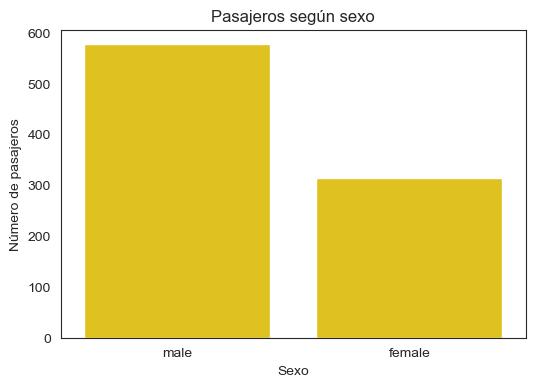

In [4]:
plt.figure(figsize=(6,4))

sns.countplot(data=titanic, x="Sex", color="gold")

plt.xlabel("Sexo")
plt.ylabel("Número de pasajeros")
plt.title("Pasajeros según sexo")

plt.show()


### Ahora usted

**1. Grafique la cantidad de pasajeros según `Pclass`.**

- Qué clase contiene más pasajeros?

**La clase que contiene más pasajeros es la clase 3 (la más baja).**

- La muestra está balanceada entre las tres clases?

**No está balanceada, pues hay una mucho mayor cantidad de pasajeros de la clase 3 (mayor al doble de cada una de las otras dos), mientras que la cantidad de pasajeros en las clases 1 y 2 son similares. Esto es esperable también, pues la clase 3 habrá gastado una menor tarifa para subir al titanic, aumentando la cantidad de tickets vendidos.**


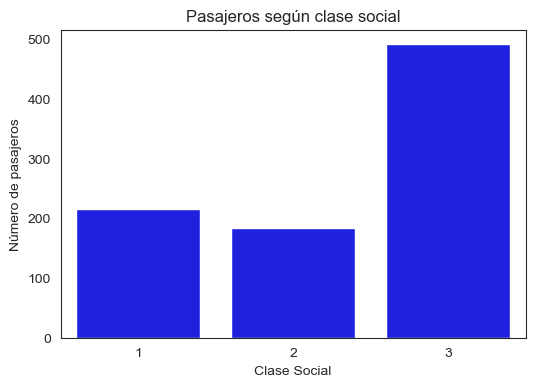

In [5]:
plt.figure(figsize=(6,4))

sns.countplot(data=titanic, x="Pclass", color="blue")

plt.xlabel("Clase Social")
plt.ylabel("Número de pasajeros")
plt.title("Pasajeros según clase social")

plt.show()

**2. Explore la distribución de `Age` con un histograma.**

Pruebe, por ejemplo, con 15, 30 y 50 bins.

- ¿Qué edades son más frecuentes?

**Las edades más frecuentes rondan entre los 20 y 30.**

- ¿La distribución parece simétrica?

**Si observamos los gráficos, si pareciera haber una distribución simétrica, similar\na una gaussiana. Esto tiene sentido, pues en el viaje es más normal la presencia de adultos que esten entre los 20 y 40, mientras que\nedades menores o mayores son menos recurrentes dada su situación económica o su energía vital.**

- ¿El número de bins cambia su interpretación?

**De los gráficos se observa que al modificar la cantidad de bins, este pareciera ser un poco diferente. Los valores no cambian, pero si el rango de edades de cada barra. Una mayor cantidad de bins implica una mayor precisión en las edades, sin embargo, eso no necesariamente es lo que queremos, pues la idea de un histograma es analizar un comportamiento basado en una parte de un grupo o comunidad. Aumentar la cantidad de bins de manera excesiva sería más similar a analizar cuantas personas tenían un número específico como edad (ej. cuantas personas en el titanic tenían exactamente 30 años), pero esto no nos interesa, pues queremos generalizar para hacer una aproximación de un rango.**


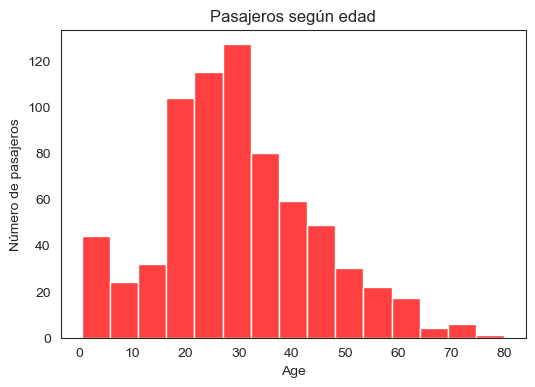

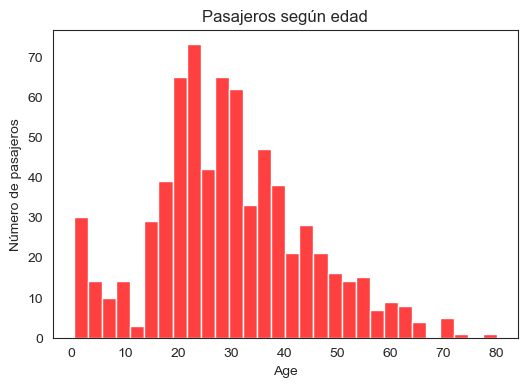

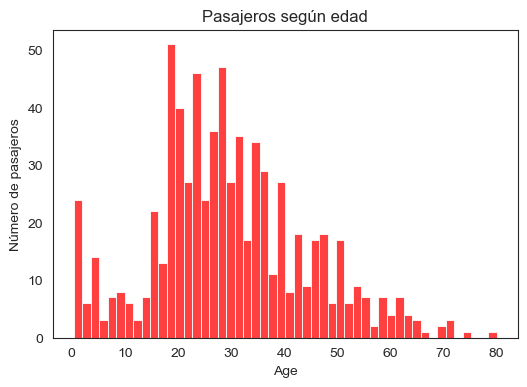

In [6]:
for i in [15, 30, 50]:
    plt.figure(figsize=(6,4))

    sns.histplot(data=titanic, x="Age", bins=i, color="red")

    plt.xlabel("Age")
    plt.ylabel("Número de pasajeros")
    plt.title("Pasajeros según edad")

    plt.show()

**3. Explore la distribución de `Fare`.**

Puede usar un histograma o un boxplot.

- ¿La distribución es simétrica?

**La distribución no es para nada simétrica, pues en ambos gráficos observamos un gran desfase de los datos. En este caso, observamos que la mayor parte de los pasajeros pagó en las tarifas más baratas (esperable, según lo que se mencionó en la parte de clases), mientras que otros pagaron tarifas mucho más altas que el resto.**

- ¿Existen tarifas muy superiores al resto?

**Sí. Existen tarifas que son increíblemente mayores al resto, siendo estas una minoría, pero que se alejan mucho del promedio pagado.**

- ¿Qué podría significar esto?

**Esto podría significar que la diferencia de clases sociales era demasiado alta, pues mientras la gran mayoría pagaba tarifas bajas, otros pagaban tarifas sumamente altas con lujos y prestigios que el resto no poseía.**


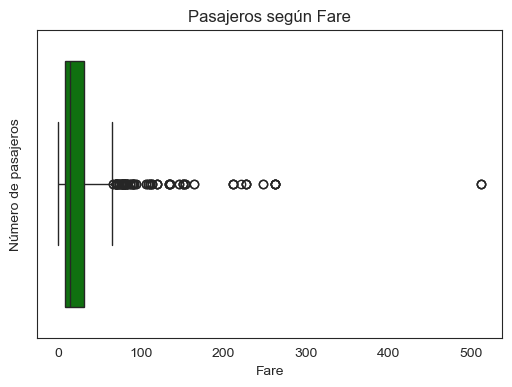

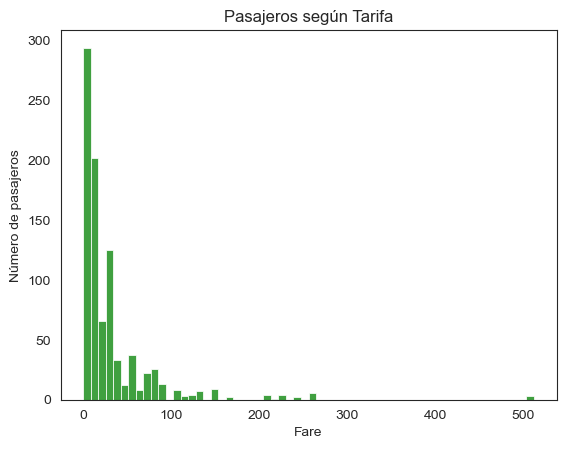

In [7]:
plt.figure(figsize=(6,4))

sns.boxplot(data=titanic, x="Fare", color="green")

plt.xlabel("Fare")
plt.ylabel("Número de pasajeros")
plt.title("Pasajeros según Fare")

plt.show()

sns.histplot(data=titanic, x="Fare", color="green")

plt.xlabel("Fare")
plt.ylabel("Número de pasajeros")
plt.title("Pasajeros según Tarifa")

plt.show()

# Parte 2: Calidad de los datos

## ¿Qué información falta y por qué podría importar?

Antes de interpretar cualquier patrón debemos revisar la calidad de los datos.

Nos interesa detectar:

- valores faltantes
- características con mucha información incompleta
- valores extremos o sospechosos
- decisiones de limpieza que puedan cambiar nuestras conclusiones


In [8]:
datos_faltantes = titanic.isnull().sum()
datos_faltantes


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

### Ejemplo de gráfico: valores faltantes

Podemos visualizar cuántos datos faltan en cada característica.


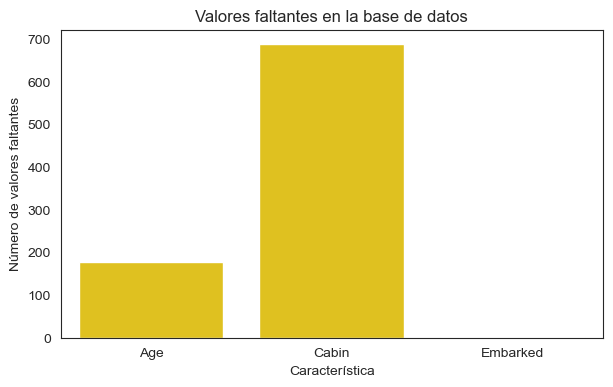

In [9]:
faltantes = datos_faltantes[datos_faltantes > 0]

plt.figure(figsize=(7,4))

sns.barplot(x=faltantes.index, y=faltantes.values, color='gold')

plt.xlabel("Característica")
plt.ylabel("Número de valores faltantes")
plt.title("Valores faltantes en la base de datos")

plt.show()


### Ahora usted

Observe especialmente `Age`, `Cabin` y `Embarked`.

**1. Compare la media y la mediana de `Age`.**

- Son similares?

**El valor de la mediana (sin considerar los NaNs) es: 28.0, mientras que el valor de la media es: 29.7.**
**Los valores estan cerca, pero hay una diferencia de casi 2 años.**

- Es la media una buena representación de una edad típica?

**La media se suele utilizar para determinar un valor típico de alguna característica, sin embargo, no necesariamente podría ser una buena representación, pues en este caso el rango de edades varía mucho desde jóvenes, adultos, y adultos mayores, por lo que podría ser (como ejemplo) más pausible en este caso calcular una media para esos 3 rangos de edades.**


**2. La edad tiene datos faltantes.**

- Le parece razonable reemplazar todas las edades faltantes por la media?

**En casos de estudios donde la variación de magnitud entre los datos no es tan grande podría ser una idea razonable, pero en este caso no me parece. Primero que todo, la cantidad de datos faltantes representa una gran porción de la cantidad total (aproximadamente el 20%), por lo que incluir tantos datos con el mismo valor desequilibraría el histograma de edades, resultando en que haya una cantidad exageramente grande de pasajeros con 29 años. Segundo, y es que como se mencionó antes, debido a la gran variación de datos (edades muy bajas y otras muy altas), la media no representa necesariamente un buen valor típico, por lo que de todas maneras no sería buena opción.**

- Qué problema podría producir esa decisión en la distribución de edades?

**El problema que produciría en la distribución sería el desbalance mencionado, lo que inflaría demasiado un cierto rango de edades, excluyendo totalmente la presencia de los rangos que se salen de la media.**

- Qué otra estrategia consideraría?

**Mi estrategia sería calcular un estimado de la edad en ciertos grupos en función de otro parámetro presente. En este caso, personalmente creo que sería efectivo utilizar las clases sociales para determinar que promedio de edades tenía cada clase (resultando en 3 promedios), y reemplazando estos valores en la distribución. Esta opción me parece válida, pero personalmente optaría mejor por definir un rango cerrado de edades para cada clase, y asignar un valor aleatorio dentro de ese rango para que no haya una inflación de un único valor en los datos.**


**3. `Cabin` tiene una gran cantidad de valores faltantes.**

- Intentaría rellenarlos?

**Para esto tengo en cuenta dos grandes consideraciones:**
1. **¿Es realmente necesario este dato? Creo que si tenemos información de las ubicaciones de cada cabina en el titanic, este dato podría ser relevante, pues aquellos pasajeros que estuviesen en los pisos más bajos de la embarcación se habrían ahogado primero (eso en caso de que estuviesen en sus habitaciones al momento). Pero la verdad es que sin está información, y con la presencia de muchos otros factores más, no me parece realmente necesaria.**
2. **Si la modelara utilizando otro factor, ¿Sería cercano al valor real mi resultado? La verdad es que dado que hay tan pocos valores de cabinas de pasajeros, creo que el resultado no tendría tanta validez, pues estaría tratando de suponer demasiados datos utilizando una muestra real muy baja. En caso de que se quisiese hacer, el factor más relacionado a este podría ser la tarifa pagada, sin embargo, tampoco tenemos información de los sectores en los que se ubicaban cada cabina (ordenados por tarifa).**

- Eliminaría la característica?

**Con la presencia de los otros factores, y con una mayor cantidad de información sobre ellos, yo sí descartaría está información. En caso de que hubiesen más datos sobre esta característica (ojalá más de la mitad del total de pasajeros), entonces la dejaría, modelaría, y utilizaría como una fuente de información viable, pero con un pequeño mayor margen de error.**

- Podría el hecho de conocer o no la cabina contener información por sí mismo?

**Sí. Podría contener información relevante, pues como se mencionó antes, si conocemos la ubicación de cada cabina en la embarcación, entonces sabremos que pasajeros fueron más propensos a ahogarse antes o quedar atrapados. También, la cabina pagada nos da información de la situación socioeconómica del pasajero (que ya veremos que es relevante para la supervivencia de estos), aunque para esto también tenemos el valor de las tarifas pagadas.**


**4. `Embarked` tiene pocos datos faltantes.**

- Qué estrategia simple usaría en este caso?

**Dado que la cantidad de datos faltantes en esta característica son tan pocos, simplemente calcularía un promedio para determinar el puerto de embarque más utilizado, y lo reemplazaría directamente. Otras opciones necesitarían la presencia de más información, por ejemplo, si quisiesemos relacionar el puerto de embarque con al tarifa pagada o con la clase socioeconómica (ubicación del puerto).**

- Por qué el tratamiento puede ser distinto al de `Cabin`?

**El tratamiento puede ser distinto debido a que la cantidad de datos faltante en este caso son muy pocas, a diferencia de cabin, cuya cantidad de datos faltantes es casi del 80%. Por lo tanto, realizar un promedio simple en este caso no nos generaría tanta pérdida o error, mientras que en el caso de cabin si lo haría.**


# Parte 3: Explorar relaciones entre características

## ¿Cómo se relacionan las características de los pasajeros?

Después de estudiar las características individualmente, podemos comenzar a buscar estructura en los datos.

Preguntas posibles:

- La tarifa pagada está relacionada con la clase?
- Las edades son similares en todas las clases?
- Quiénes viajaban acompañados?
- Hay características que contienen información parcialmente similar?

(estas son preguntas retoricas, las que se responden son las siguientes)

### Ejemplo de gráfico: tarifa según clase

Un boxplot permite comparar la distribución de una característica numérica entre distintos grupos.


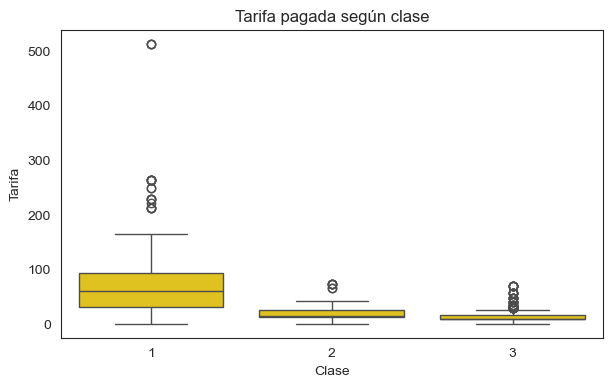

In [10]:
plt.figure(figsize=(7,4))

sns.boxplot(data=titanic, x="Pclass", y="Fare", color='gold')

plt.xlabel("Clase")
plt.ylabel("Tarifa")
plt.title("Tarifa pagada según clase")

plt.show()


### Preguntas

- La tarifa parece estar relacionada con la clase?

**Sí. Las tarifas pagadas están relacionadas con las clases, y es de esperar, pues aquellos que son de mayor clase pagan tarifas muchos más grandes. Esto se ve en el BoxPlot, en donde si consideramos únicamente los cuartiles vemos que la clase más alta paga tarifas más altas también, lo que se observa como un diagrama desplazado hacia arriba en comparación al resto. Luego, considerando también los outliers, vemos que la clase 1 posee outliers que pagan tarifas muchos más altas también. Algo curioso es que la clase que menos outliers tiene es la clase 2 (que también es la clase que menos pasajeros tiene).**

- Hay dispersión dentro de cada clase?

**Si hay dispersión, principalmente en la clase 1 y 3, pues son las que más outliers tienen, demostrando una gran cantidad de pasajeros que compraron tickets con tarifas muy fuera del promedio, mientras que aquellos en la clase 2 tienen una menor dispersión.**

- Existen valores extremos?

**Para la tarifa más baja no pareciera haber un valor extremo... osea, obviamente hay una tarifa mínima pagada, en este caso, por la clase 3. Sin embargo, este valor cabe dentro de un promedio entre los cuartiles, por lo que a través de los gráficos no es posible determinar este valor. Por otra parte, para la tarifa más alta si es posible determinar un valor extremo, pues notamos que hay un pasajero que pago una tarifa mucho más grande al resto, de aproximadamente $500 US (supongo que son US).**

- Diría que `Fare` y `Pclass` contienen exactamente la misma información?

**No. Aunque ambos parámetros están directamente relacionados, no diría que contienen la misma información, pues la clase podría servir como un promedio de tarifa pagada por dicha clase, pero la presencia de outliers dispersa nuestros datos y desplaza el promedio real de tarifas en cada clase. Por ende, las clases entregan un valor promedio de las tarifas pagadas por cada una de estas, lo cual es eficiente en sí, pero las tarifas nos dejan conocer la presencia de outliers y que magnitud hubo de cada uno de ellos.**


### Ahora usted

**1. Compare la distribución de edad entre las tres clases.**

Use un gráfico que permita comparar las distribuciones.

- Los pasajeros tienen edades similares en todas las clases?

**Aquí observamos resultados bastante distintos para cada clase. En la clase 1 vemos que hay una distribución bastante uniforme entre los resultados, sin presencia de outliers. Por otra parte, la clase 3 presenta outliers en edades que están sobre la distribución promediada. Por último, la clase 2 presenta outliers por encima y por debajo de la distribución promediada.**

- Qué diferencias observa?

**Las diferencias que presenciadas son las mencionadas anteriormente, sobre la presencia de outliers en cada clase. Esto nos ayuda a deducir que la clase 1 permanece todo dentro de un rango específico de edades, es decir, los pasajeros dentro de esta clase son todos de edades similares. La clase 3 tiene pasajeros que están por sobre el promedio, es decir, hubo presencia de algunas personas más mayores que pagaron en estas tarifas más baratas, mientras que la clase 2 tiene algunos que son mayores o otros menores al promedio.**

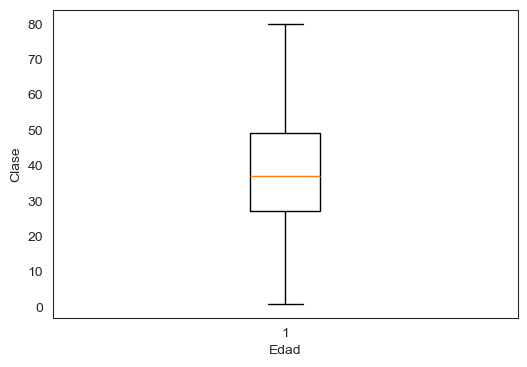

La media es: 38.2 y la mediana: 37.0


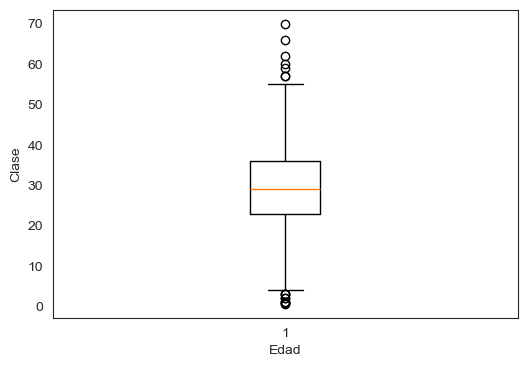

La media es: 29.9 y la mediana: 29.0


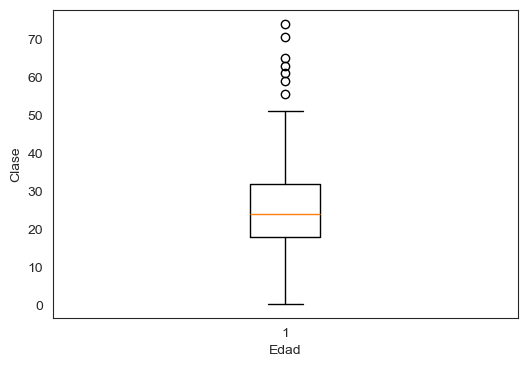

La media es: 25.1 y la mediana: 24.0
La edad más baja es: 0.42


In [11]:

for i in [1,2,3]:
    plt.figure(figsize=(6,4))
    datos = titanic[(titanic["Age"].notnull()) & (titanic["Pclass"] == i)]
    plt.boxplot(data=datos, x="Age")

    plt.xlabel("Edad")
    plt.ylabel("Clase")

    plt.show()
    print(f'La media es: {np.mean(datos["Age"]):.1f} y la mediana: {np.median(datos["Age"]):.1f}')

print(f'La edad más baja es: {titanic["Age"].min()}')

In [12]:
titanic.loc[titanic["Age"].isna() & (titanic["Pclass"] == 1), "Age"] = 38.2
titanic.loc[titanic["Age"].isna() & (titanic["Pclass"] == 2), "Age"] = 29.9
titanic.loc[titanic["Age"].isna() & (titanic["Pclass"] == 3), "Age"] = 25.1

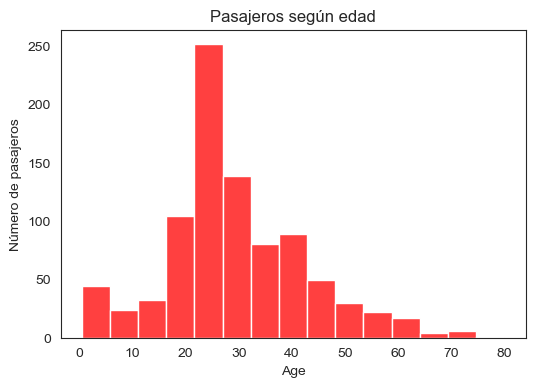

In [13]:
plt.figure(figsize=(6,4))

sns.histplot(data=titanic, x="Age", bins=15, color="red")

plt.xlabel("Age")
plt.ylabel("Número de pasajeros")
plt.title("Pasajeros según edad")

plt.show()

**2. Las características `SibSp` y `Parch` contienen información sobre familiares a bordo.**

Construya una nueva característica llamada `Familia`, que represente el número total de personas del grupo familiar incluyendo al propio pasajero:

\[
Familia = SibSp + Parch + 1
\]


In [14]:
titanic["Familia"] = titanic["SibSp"] + titanic["Parch"] + 1
titanic["Familia"]

0      2
1      2
2      1
3      2
4      1
      ..
886    1
887    1
888    4
889    1
890    1
Name: Familia, Length: 891, dtype: int64

In [15]:
print(titanic["Familia"].value_counts().sort_index())
print(f'La cantidad de pasajeros que NO viajan solos son: {titanic["Familia"].value_counts().drop(1).sum()}')
print(f'La cantidad de pasajeros que viajan solos son: {(titanic["Familia"] == 1).sum()}')

Familia
1     537
2     161
3     102
4      29
5      15
6      22
7      12
8       6
11      7
Name: count, dtype: int64
La cantidad de pasajeros que NO viajan solos son: 354
La cantidad de pasajeros que viajan solos son: 537


**3. Explore la nueva característica `Familia`.**

- La mayoría de los pasajeros viajaba sola o acompañada?

**La mayor parte de los pasajeros viajaba sola, habiendo 183 pasajeros más que viajaron solos en comparación a los que viajaron acompañados.**

- Hay grupos familiares muy grandes?

**Sí. Aunque en comparación a las familias más pequeñas (2 a 3 integrantes), estos están en menor cantidad, pero si hay presencia de grupos que son demasiados grandes, incluyendo familias de 11 integrantes.**

- Cambiaría su interpretación si solo mirara `SibSp` o `Parch` por separado?

**Aunque si entregan información diferente (quienes viajan con padres o hijos/quienes viajan con hermanos o conyuges), está información por si sola no es tan relevante para conocer que cantidad de supervivientes hubieron, pues de manera más general y simplificada conocer la cantidad de personas relacionadas entre sí que abordaron el titanic es más que suficiente para realizar un análisis. Finalmente, al análisis de que pasajeros que viajaban con familiares tuvieron una menor tasa de supervivencia se mantendrá tanto para la característica SibSp y Parch**


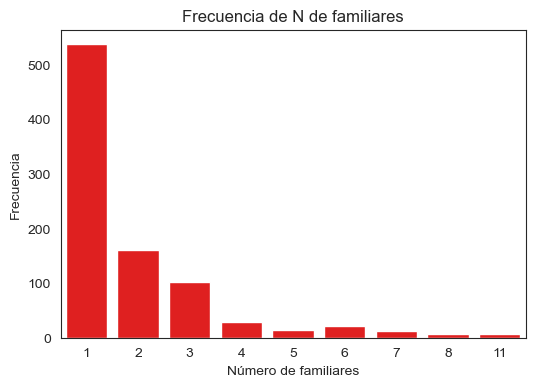

In [16]:
plt.figure(figsize=(6,4))

sns.countplot(data=titanic, x="Familia", color='red')

plt.xlabel("Número de familiares")
plt.ylabel("Frecuencia")
plt.title("Frecuencia de N de familiares")

plt.show()

# Parte 4: Investigar la supervivencia

## ¿Qué características estaban asociadas con la supervivencia?

Ahora incorporaremos `Survived`, la variable que queremos comprender.

Investigaremos si la supervivencia está asociada con características como:

- sexo
- clase
- edad
- tamaño del grupo familiar


### Ejemplo de gráfico: supervivencia según sexo

Como `Survived` toma valores 0 y 1, su promedio dentro de un grupo corresponde a la **fracción de pasajeros que sobrevivió**.

`seaborn.barplot` calcula por defecto la media de la variable del eje vertical.


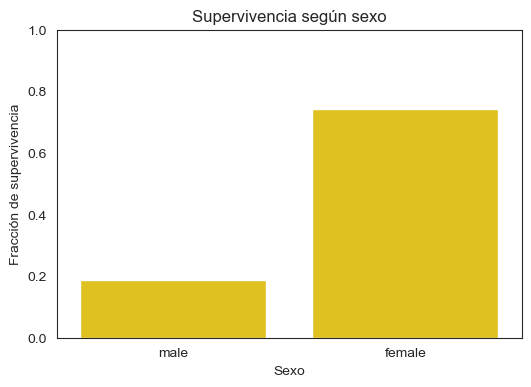

In [17]:
plt.figure(figsize=(6,4))

sns.barplot(data=titanic, x="Sex", y="Survived", errorbar=None, color='gold')

plt.xlabel("Sexo")
plt.ylabel("Fracción de supervivencia")
plt.title("Supervivencia según sexo")
plt.ylim(0,1)

plt.show()


### Preguntas

- La fracción de supervivencia es similar para hombres y mujeres?

**No. En el gráfico se observa que la cantidad de supervivientes mujeres fue aproximadamente 4 veces mayor que la cantidad de supervivientes hombres.**

- Podemos concluir a partir de este gráfico por qué existe la diferencia?

**Con el gráfico en sí no podemos concluir una razón 100% segura de la razón de la existencia de esta diferencia, pero podemos inferir algunas cosas considerando también la época en la que ocurrió. En este caso, podemos suponer que en aquel tiempo se le daba más prioridad a las mujeres antes que a los hombres para que pudieran abordar botes de sobrevivencia, pero nuevamente esto es una inferencia en la cual se debió de tener en cuenta otra pieza de información: El año en el que ocurrió este suceso.**


### Ahora usted

**1. Explore la supervivencia según `Pclass`.**

- Hay diferencias entre las tres clases?

**Sí. Existe una diferencia entre las clases sociales que tuvieron un mayor índice de supervivencia, siendo aquellas clases más altas las que tuvieron más supervivientes, y las clases más bajas las que tuvieron una menor cantidad de supervivientes.**

- Existe una tendencia?

**Si hay una tendencia bastante obvia, que se podría apreciar una tendencia directamente proporcional entre la clase social y la cantidad de supervivientes, por lo que mientras mayor sea la clase, mayor cantidad de supervivientes tendrá (ya que se les dará prioridad).**


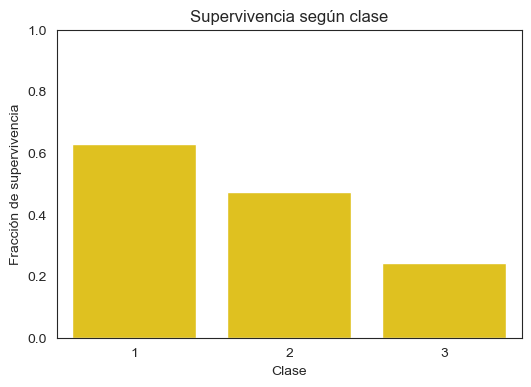

In [18]:
plt.figure(figsize=(6,4))

sns.barplot(data=titanic, x="Pclass", y="Survived", errorbar=None, color='gold')

plt.xlabel("Clase")
plt.ylabel("Fracción de supervivencia")
plt.title("Supervivencia según clase")
plt.ylim(0,1)

plt.show()

**2. Explore la supervivencia según edad.**

Puede comparar las distribuciones de edad de quienes sobrevivieron y quienes no sobrevivieron.

- La edad parece estar asociada con supervivencia?

**Las condiciones para la superviviencia están dadas por distintas razones que podría haber influenciado, sin embargo, es posible notar que hasta los 15 años aproximadamente hubo un mayor índice de supervivencia que en otros rangos de edades. Por lo tanto, se podría decir que hasta este punto si hubo un mayor índice de supervivencia (aunque aquí no estamos considerando cuantos chicos de cada rango de edad habían inicialmente, por lo que cada valor gráficado no necesariamente está directamente relacionado con la supervivencia. A lo que me refiero con esto es que un rango de edades puede tener un 100% de supervivencia, pero solo tener 1 sobreviviente en esa edad, mientras que otro rango de edades puede tener 1 superviviente y 1 fallecido y ya es considerado como un 50% de superviviencia).**

- Hay algún grupo de edad que llame particularmente su atención?

**El grupo de edades que más llama la atención es el de edades más bajas, que como se mencionó antes tiene un mayor índice de supervivencia, como así también, pero en menor magnitud, algunos rangos de edades mayores, que honestamente dada la época considero más que es probable que sean de clase más altas, ya que en esta situación adultos mayores podrían darse por muertos desde un inicio.**


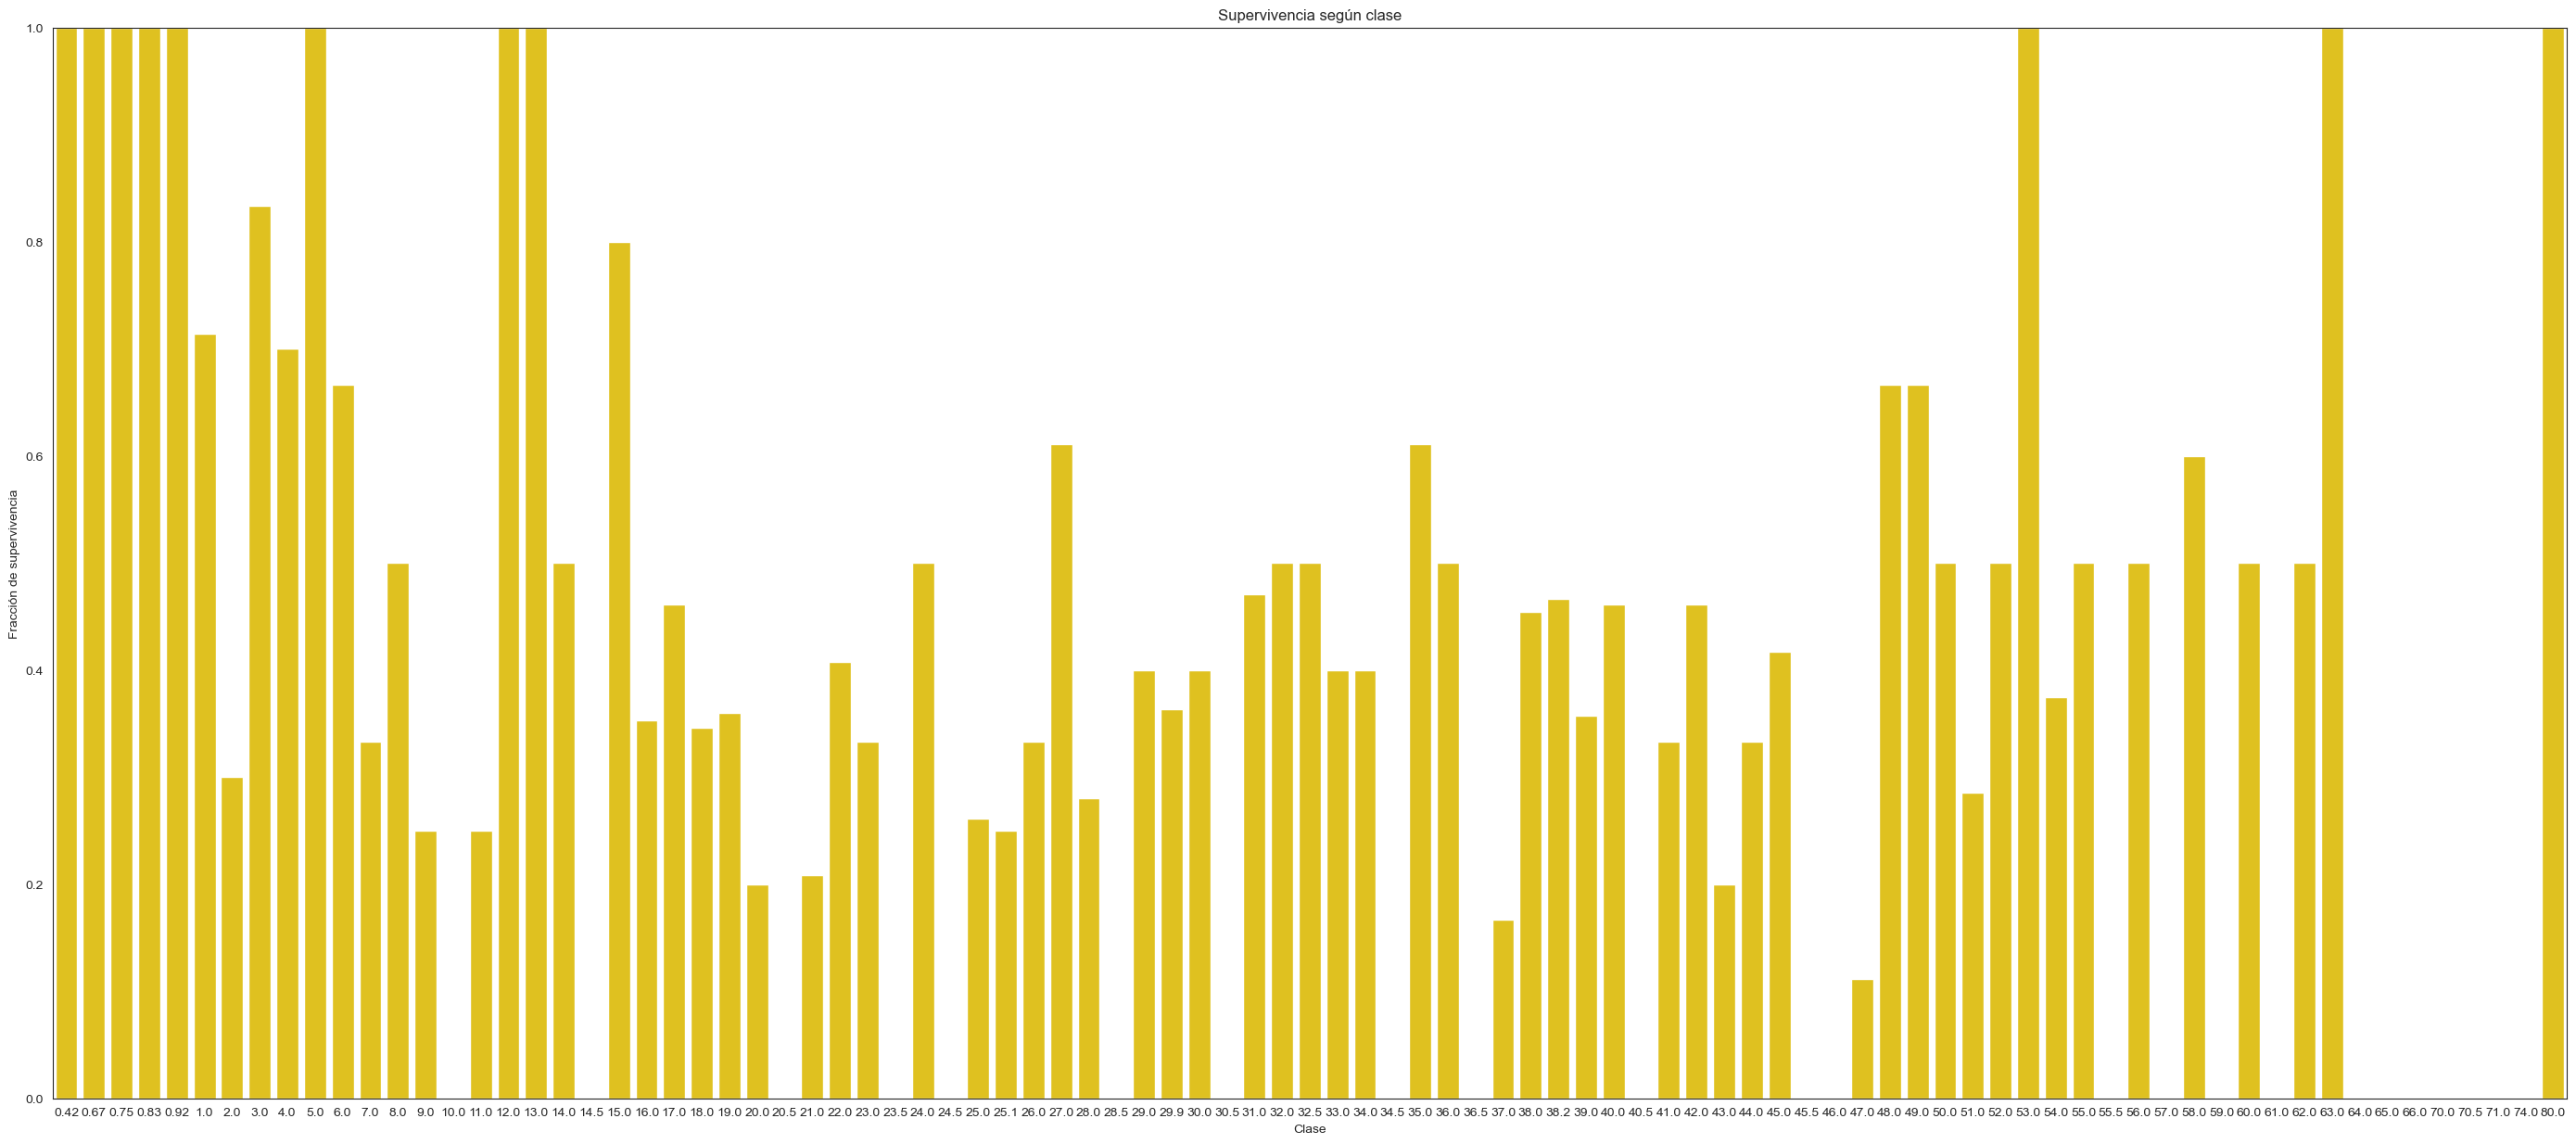

In [19]:
plt.figure(figsize=(35,15))

sns.barplot(data=titanic, x="Age", y="Survived", errorbar=None, color='gold')

plt.xlabel("Clase")
plt.ylabel("Fracción de supervivencia")
plt.title("Supervivencia según clase")
plt.ylim(0,1)

plt.show()

**3. Explore la supervivencia según `Familia`.**

- Viajar solo parece favorable o desfavorable?

**Aquí hay un punto intermedio, ya que viajar solo no parece tan favorable, pero viajar en familias tan grandes es peor aún. Por lo tanto, las familias más pequeñas tuvieron mejor oportunidad de sobrevivir juntos.**

- La relación parece simple?

**La verdad no parece una relación tan simple. Podría considerarse como una campana de Gauss, donde el grupo familiar con más supervivientes sería de 4, y la superviviencia de otros grupos disminuye hacia ambas direcciones.**

- Qué ocurre con los grupos familiares grandes?

**Grupos familiares tan grandes tienen menos probabilidades de sobrevivir todos juntos, esto debido a que es más fácil que un integrante tenga algún disfortunio y perjudique al resto. Además, se les da prioridad a la supervivencia de más familias, por lo que no integrar familias muy grandes sería considerado injusto por no darle la oportunidad a otras personas.**


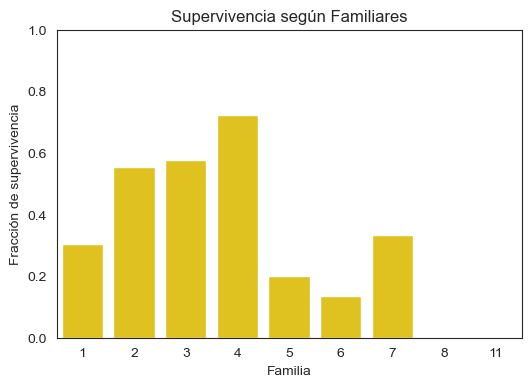

In [20]:
plt.figure(figsize=(6,4))
sns.barplot(data=titanic, x="Familia", y="Survived", errorbar=None, color='gold')

plt.xlabel("Familia")
plt.ylabel("Fracción de supervivencia")
plt.title("Supervivencia según Familiares")
plt.ylim(0,1)

plt.show()



# Parte 5: Agregar contexto

## ¿Cambia una relación cuando consideramos otra característica?

Una relación global puede esconder comportamientos diferentes dentro de la muestra.

Ya estudiamos por separado:

- `Pclass` y supervivencia
- `Sex` y supervivencia

Ahora podemos preguntar:
 **¿La relación entre clase y supervivencia es igual para hombres y mujeres?**

Esta es una forma sencilla de análisis multivariado: consideramos varias características al mismo tiempo.


### Ejemplo de gráfico: clase, sexo y supervivencia


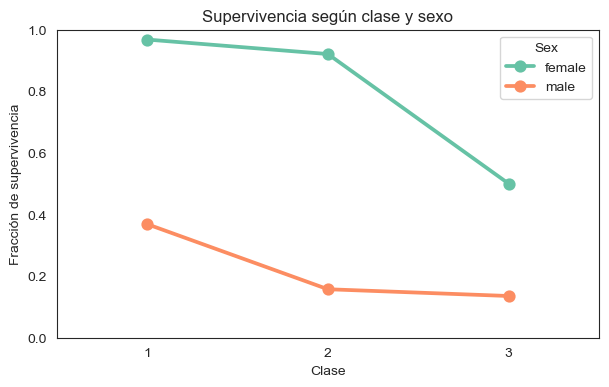

In [21]:
plt.figure(figsize=(7,4))

sns.pointplot(data=titanic,
              x="Pclass",
              y="Survived",
              hue="Sex",
              palette="Set2",
              errorbar=None)

plt.xlabel("Clase")
plt.ylabel("Fracción de supervivencia")
plt.title("Supervivencia según clase y sexo")
plt.ylim(0,1)

plt.show()


### Preguntas sobre el ejemplo

- La relación entre clase y supervivencia es igual para hombres y mujeres?

**La relación de mayor clase -> mayor índice de supervivencia si se cumple tanto para hombres como para mujeres, aunque es menos evidente en hombres.**

- Qué información se perdía cuando mirábamos solamente `Pclass`?

**La información que se perdía es que no sabemos cuantos hombres y cuantas mujeres sobrevivían en cada clase. Tendríamos que suponer si es que estaban en misma magnitud, o si es que había una preferencia por un sexo o el otro, y esto tendría que considerarse para las 3 clases de manera separada.**

- Qué información se perdía cuando mirábamos solamente `Sex`?

**Cuando mirabamos solamente el sexo, la información que se perdía era de que clase sobrevivían más para cada sexo. Por ejemplo, sabemos que sobrevivían más mujeres, pero ¿Esto se cumple para las 3 clases?**

- Hay algún grupo particularmente favorecido o desfavorecido?

**El grupo más favorecido son las mujeres de clase 1, donde observamos que tuvieron una supervivencia de casi el 100%. Por otra parte, el grupo más desfavorecido son los hombres de clase 2 y 3 (principalmente los de clase 3, pero en magnitudes similares).**



### Ahora usted

**1. Cree una característica `Persona` con tres categorías:**

- `mujer`
- `hombre`
- `niño/a`

Considere como niño/a a un pasajero menor de 16 años.


In [22]:
def clasificar(pasajero):
    edad = pasajero["Age"]
    sexo = pasajero["Sex"]

    if edad < 16:
        return "Niño/a"
    elif sexo == "male":
        return "Hombre"
    elif sexo == "female":
        return "Mujer"

titanic["Persona"] = titanic.apply(clasificar, axis=1)

titanic["Persona"].value_counts()


Persona
Hombre    537
Mujer     271
Niño/a     83
Name: count, dtype: int64

**2. Explore la supervivencia según `Persona` y `Pclass`.**

- Los niños presentan el mismo patrón que los adultos?

**Sorprendentemente no, los niños no presentan el mismo patrón que los adultos, pues se observa que los niños con mayor porcentaje de supervivencia fueron los de clase 2. Tampoco podemos decir que la supervivencia de niños fue mayor o menor a la de mujeres u hombres, ya que su forma irregular la mezcla con la cantidad de supervivientes mujeres en distintas clases.**

- La clase sigue siendo importante dentro de cada grupo?

**A pesar de la diferencia en el resultado, aún se sigue esperando que la clase sea importante dentro de cada grupo, pues en función de los resultados que hemos obtenidos hasta ahora, que los niños de clase 1 tengan un menor porcentaje de supervivencia no es lo esperable, sin embargo, también debemos de considerar que la supervivencia de niños tan pequeños (ya que había menores de 1 año inclusive) es una variable más difícil de controlar, además de que se debe de considerar que cantidad de niños estaban presentes en el titanic (veáse del segundo gráfico que en la clase 1 habían solamente 5 niños app, mientras que en la clase 2 habían 20 app).**

- Qué combinación de características parece asociarse con la mayor supervivencia?

**La combinación de características que mejor se asocia con la supervivencia es mujer/niño (principalmente mujer) y clase alta.**


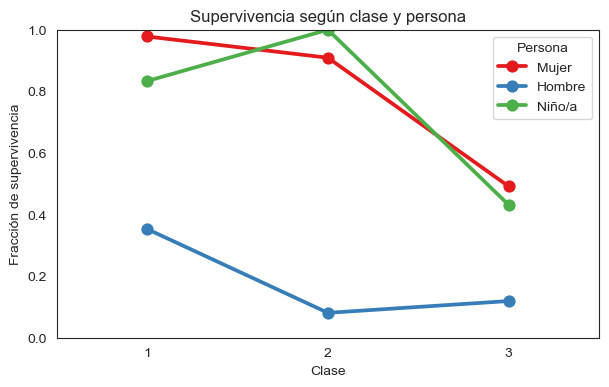

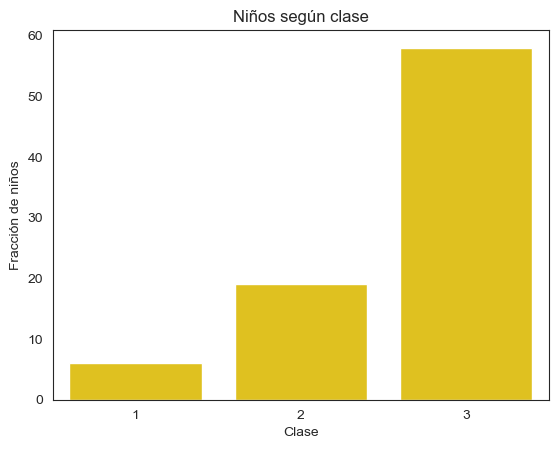

In [23]:
plt.figure(figsize=(7,4))

sns.pointplot(data=titanic,
              x="Pclass",
              y="Survived",
              hue="Persona",
              palette="Set1",
              errorbar=None)

plt.xlabel("Clase")
plt.ylabel("Fracción de supervivencia")
plt.title("Supervivencia según clase y persona")
plt.ylim(0,1)

plt.show()

sns.countplot(data=titanic[titanic["Persona"] == "Niño/a"], x="Pclass", color="gold")
plt.xlabel("Clase")
plt.ylabel("Fracción de niños")
plt.title("Niños según clase")

plt.show()

**3. Elija una relación adicional para explorar incorporando una tercera característica.**

Algunas ideas:

- edad + sexo + supervivencia;
- tamaño de familia + clase + supervivencia;
- puerto de embarque + clase + supervivencia.

No necesita crear una figura complicada. El objetivo es responder una pregunta concreta.

**Escriba primero la pregunta que quiere investigar y luego construya el gráfico.**

### *Pregunta: ¿Existe una relación entre las clases y el puerto de embarque? En caso de que si, ¿En que puerto se pagan mayores tarifas?*

**Se puede observar que la clase 1 abordo principalmente en el puerto S y C, mientras que el Q fue notablemente más abordado por pasajeros de la clase 3. En total, se ve que el puerto más abordado de todos (por las 3 clases) fue el S, y las tarifas más altas pagadas por las clases 2 y 3 se encuentran en este. En el caso de la clase 1, las tarifas más altas pagadas están en el puerto C, sin embargo, estos son 3 outliers, mientras que el resto de pasajeros pago tarifas similares a las pagadas en el embarque S. Por ende, se puede deducir que el puerto S está ubicado en un lugar más alto socialmente, mientras que el puerto Q está en un lugar más bajo. Sin embargo, el puerto C también es alto económicamente, y en este embarcaron los pasajeros que más pagaron por el viaje.**


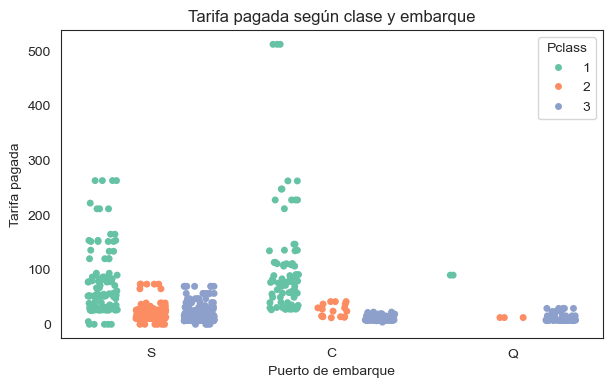

In [24]:
plt.figure(figsize=(7,4))

#sns.barplot(data=titanic, x="Familia", y="Survived", hue="Embarked", errorbar=None)
sns.stripplot(data=titanic, x="Embarked", y="Fare", hue="Pclass", dodge=True, jitter=0.25, palette="Set2")

plt.xlabel("Puerto de embarque")
plt.ylabel("Tarifa pagada")
plt.title("Tarifa pagada según clase y embarque")

plt.show()

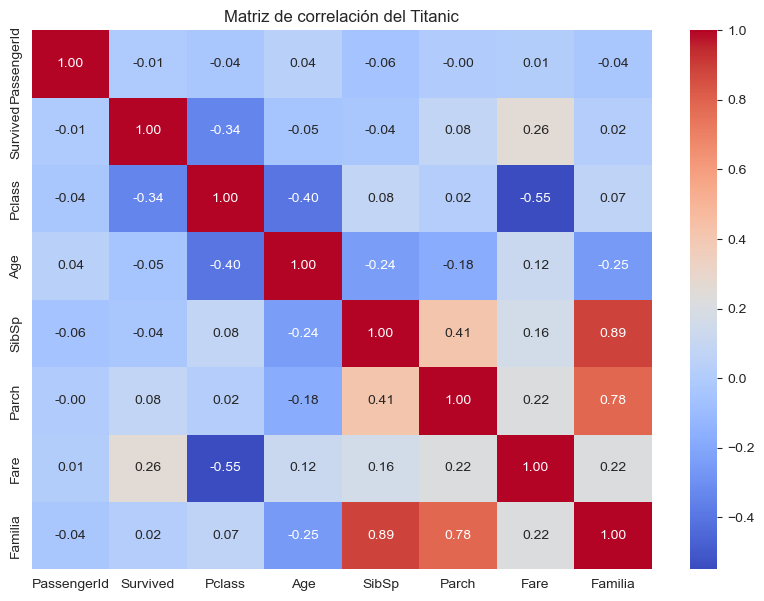

In [25]:
corr_matrix = titanic.corr(numeric_only=True) 
plt.figure(figsize=(10, 7))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Matriz de correlación del Titanic")
plt.show()

# Parte 6: Conclusión

## ¿Qué podemos concluir?

El EDA no termina cuando encontramos diferencias entre grupos.

Queremos distinguir entre:

### Observación
Algo que vemos directamente en los datos.

### Interpretación
Cómo describimos ese patrón.

### Hipótesis
Una explicación posible que debería ser evaluada con más información.

Por ejemplo:

> **Observación:** las mujeres presentan una mayor fracción de supervivencia que los hombres.

- **Podemos concluir, solo a partir de esta base de datos, que durante la evacuación se dio prioridad a mujeres y niños?**

**Si se considera únicamente la base de datos para realizar una conclusión como está, entonces no podría ser posible asegurarlo, pues razones para que esto suceda podrían haber muchas. Para nosotros concluir que se les dio prioridad a las mujeres y niños podría parecer algo simple y hasta evidente. Sin embargo, eso es porque nosotros tenemos un contexto ético-social, lo que nos da la ventaja de que sabemos que en aquella época y bajo situaciones como está se solía priorizar a las mujeres (por labor de madre/progenitoras) y a los niños (por razones de futuro) por sobre los hombres. Si se desconociese está información, entonces utilizar está base de datos para llegar a esa conclusión no podría ser tan seguro, pues no habría contexto y razones pueden haber miles.**

- **Qué información adicional necesitaríamos para evaluar esa hipótesis?**

**Lo que fue mencionado anteriormente. La información que necesitariamos para válidar la hipótesis podría ser el contexto ético y social en el año en el que ocurrió dicho suceso. Si se quisiese validar con más datos, entonces podría evaluarse que cantidad de pasajeros sobrevivió por subir a una embarcación vs la cantidad de pasajeros que sobrevivió por su cuenta.**

- **Qué otras explicaciones podrían producir el mismo patrón de supervivencia?**

**Otro patrón de superviviencia podría ser que las mujeres tomaron a sus hijos y tomaron las embarcaciones como prioridad, mientras que los hombres podría haber priorizado otro actuar antes de correr por su supervivencia (como por ejemplo: correr a borrar el porno del computador).**

## Síntesis del análisis

Revise todas las figuras construidas y responda:

### 1. Quiénes eran los pasajeros del Titanic?

Describa brevemente la muestra considerando, al menos:

- sexo
- clase
- edad
- tamaño de familia.

**Los pasajeros del titanic eran principalmente hombres, siendo ellos casi el doble que las mujeres. Sus edades iban desde los meses de edad hasta los casi 80, pero en su gran mayoría eran jovénes entre 20 y 30 años. La gran mayoría eran personas de una clase social más baja, mientras que los de clase social más alta eran menos, pero en algunos casos pagaban tarifas muy por encima del resto. La mayoría de los pasajeros viajaban solos, sin embargo, otros viajaban en grupos familiares bastantes grandes**

### 2. Qué características estaban asociadas con la supervivencia?

Considere:

- sexo
- clase
- edad
- viajar solo o acompañado.

**Los supervivientes del titanic fueron principalmente mujeres, teniendo prioridad según clase, pues la clase más alta tenía mayor índice de superviviencia en relación a las otras menores. Además de las mujeres, también sobrevivieron muchos menores, lo que se espera que hayan escapado junto a sus familiares directos, pues aquellas familias que más sobrevivieron fueron las que contenían 3 a 4 integrantes, mientras que pasajeros que viajaban solos o en grupos más grandes sobrevivieron en menor o nula cantidad.**

### 3. Qué relaciones cambiaron al considerar varias características al mismo tiempo?

Use como ejemplo al menos uno de los análisis multivariados realizados.

**La relación que más notablemente cambia al considerar varias características al mismo tiempo fue la de la supervivencia en función de la clase social y si es que estos eran adultos (hombres o mujeres) o niños. Lo esperable es que la cantidad de supervivientes disminuya aproximadamente lineal según disminuye la clase social (que es lo que se observa al analizar la cantidad de supervivientes por clase únicamente). Sin embargo, los hombres, mujeres y niños tienen comportamientos distintos. El caso esperado solo fue cumplido por el grupo de mujeres, mientras que en el grupo de hombres sobrevivieron más en la clase 3 que en la clase 2, y en los niños sobrevivieron más de la clase 2 que la clase 1.**

### 4. Encontró características que contienen información relacionada?

Explique al menos un caso.

**Sí, existen varias características que contienen información relacionada. El caso más evidente vendría siendo la tarifa pagada según la clase, donde las clases más altas pagaron tarifas bastante más altas que el resto de clases con diferencias enormes en algunos casos. Otro caso más que es posible explicar es la cantidad de supervivientes según la clase, siendo la clase más alta la que posee más supervivientes. Sin embargo, como se mencionó en la pregunta anterior, este resultado cambia al realizar un análisis más profundo según sexo y edad, por lo que no siempre es confiable decir que si están relacionadas podemos ignorar una de las dos.**

### 5. Qué resultado le pareció más inesperado?

Proponga una posible explicación, dejando claro qué parte corresponde a una observación y qué parte corresponde a una hipótesis.

**Un resultado que me pareció inesperado fue la cantidad de integrantes de familias que asistieron según clase (ver gráfico de abajo al fondo), como así también la cantidad de niños que asistieron, pues mi hipótesis antes de observar los datos había sido que las familias de clases más altas habrían asistido con más integrantes y con sus hijos, pero lo obtenido fue lo contrario. En el caso de los niños, de la clase 1 solo asistieron 5 aproximadamente, mientras que en la clase 3 asistieron bastantes más, lo que significa que las familias de clases más bajas decidieron viajar con sus hijos, mientras que las familias más adineradas decidieron viajar principalmente solos o con pocos integrantes acompañandolos. En el gráfico de frecuencias del número de integrantes por familia y clase, se observa que las familias con más de 5 integrantes hasta los 11 integrantes está principal o únicamente liderado por la clase 3, lo que vuelve a contradecir mi hipótesis inicial.**


# Conclusión final

## ¿Cuál es el perfil del pasajero típico que sobrevivió?

A partir de **sus propios resultados**, escriba una conclusión breve que caracterice al pasajero con mayor probabilidad de haber sobrevivido en esta muestra.

Considere, cuando corresponda:

- sexo
- edad
- clase
- tamaño del grupo familiar
- otras características que hayan resultado relevantes

Su respuesta debe estar respaldada por las figuras que construyó.


### Escriba aquí su conclusión

**El pasajero típico que sobrevivió fue de sexo femenino, entre 20 a 30 años de edad, de clase 1, en un grupo familiar de 4 integrantes y junto a sus hijos (menores de 16 años). El sexo, clase, y grupo familiar ya fue analizado antes, mientras que la edad de las mujeres que más sobrevivieron se pueden observar en un gráfico adicional justo debajo de este párrafo. El análisis final realizado fue que se les dio prioridad a las mujeres y niños para escapar antes que los hombres. Las mujeres de clase más alta habrán tenido más prioridad que las de clases más bajas, además de poder escapar junto a sus grupos familiares (principalmente 4 integrantes).**

### Esto es aparte, por curiosear

In [55]:
mujeres = titanic[titanic["Sex"] == "female"]

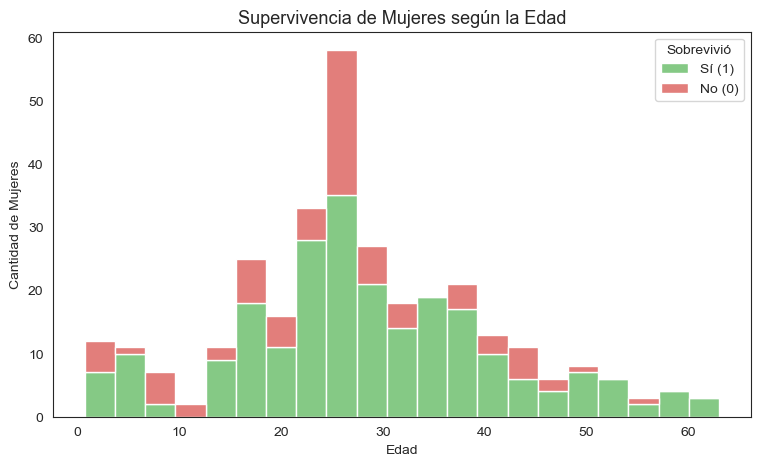

In [56]:
plt.figure(figsize=(9, 5))
sns.histplot(
    data=mujeres,
    x="Age",
    hue="Survived",
    multiple="stack",      
    palette={0: "#d9534f", 1: "#5cb85c"},  
    binwidth=3
)

plt.title("Supervivencia de Mujeres según la Edad", fontsize=13)
plt.xlabel("Edad")
plt.ylabel("Cantidad de Mujeres")
plt.legend(title="Sobrevivió", labels=["Sí (1)", "No (0)"])
plt.show()

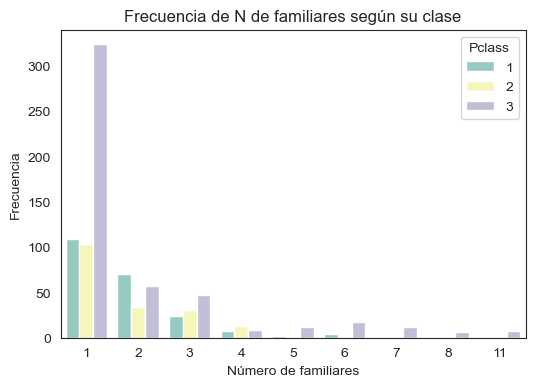

In [32]:
plt.figure(figsize=(6,4))

sns.countplot(data=titanic, x="Familia", hue="Pclass", palette="Set3")

plt.xlabel("Número de familiares")
plt.ylabel("Frecuencia")
plt.title("Frecuencia de N de familiares según su clase")

plt.show()